The aim of this project is to analyse and characterise electricity demand in Denmark using data obtained from the European Network of Transmission System Operators for Electricity (ENTSO-E). The project investigates key aspects of time-series analysis and electricity demand forecasting, with particular emphasis on the development and evaluation of forecasting models. In addition, the analysis considers the economic implications of forecast errors by examining the associated cost of prediction inaccuracies.

This project aims to answer the following questions:
1. How accurate is the ENTSO-E day-ahead electricity-load forecast, and can a machine-learning model improve upon it?
2. Under what conditions does electricity-demand forecasting become difficult?


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import holidays
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import xgboost as xgb
from sklearn.pipeline import Pipeline
import lightgbm as lgb
import shap

The dataset contains hourly timestamps (MTU, CET/CEST), along with the forecasted electricity demand (Day-ahead Total Load Forecast) and the actual electricity demand (Actual Total Load), both measured in megawatts (MW).

In [ ]:
# 1. DATA ANALYSIS
# Load data
DK1 = pd.read_csv('DK1.csv')
DK2 = pd.read_csv('DK2.csv')
display(DK1.head())
display(DK2.head())

# Ensure dtype consistency
DK1["Actual Total Load (MW)"] = pd.to_numeric(
    DK1["Actual Total Load (MW)"],
    errors="coerce"
)

DK2["Actual Total Load (MW)"] = pd.to_numeric(
    DK2["Actual Total Load (MW)"],
    errors="coerce"
)

,MTU (CET/CEST),Area,Actual Total Load (MW),Day-ahead Total Load Forecast (MW)
0,01/01/2026 00:00 - 01/01/2026 01:00,BZN|DK1,2511.33,2302.00
1,01/01/2026 01:00 - 01/01/2026 02:00,BZN|DK1,2588.73,2245.00
2,01/01/2026 02:00 - 01/01/2026 03:00,BZN|DK1,2674.85,2179.00
3,01/01/2026 03:00 - 01/01/2026 04:00,BZN|DK1,2707.59,2114.00
4,01/01/2026 04:00 - 01/01/2026 05:00,BZN|DK1,2679.36,2093.00


,MTU (CET/CEST),Area,Actual Total Load (MW),Day-ahead Total Load Forecast (MW)
0,01/01/2026 00:00 - 01/01/2026 01:00,BZN|DK2,1686.50,1642.00
1,01/01/2026 01:00 - 01/01/2026 02:00,BZN|DK2,1684.91,1596.00
2,01/01/2026 02:00 - 01/01/2026 03:00,BZN|DK2,1659.07,1551.00
3,01/01/2026 03:00 - 01/01/2026 04:00,BZN|DK2,1713.45,1509.00
4,01/01/2026 04:00 - 01/01/2026 05:00,BZN|DK2,1687.19,1477.00


In [ ]:
    # Data type
print("Data type:")
display(DK1.info())
print()

    # Duplicates
print("Duplicates:")    
print("DK1:", DK1.duplicated().sum())
print("DK2:", DK2.duplicated().sum())


Data type:
<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 4 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   MTU (CET/CEST)                      8760 non-null   str    
 1   Area                                8760 non-null   str    
 2   Actual Total Load (MW)              5646 non-null   float64
 3   Day-ahead Total Load Forecast (MW)  8760 non-null   str    
dtypes: float64(1), str(3)
memory usage: 273.9 KB


None


Duplicates:
DK1: 0
DK2: 0


In [5]:
# Descriptive statistics
# Actual Total Load (MW) - DK1
display(DK1["Actual Total Load (MW)"].describe())
# Actual Total Load (MW) - DK2
display(DK2["Actual Total Load (MW)"].describe())

# Forecasted Total Load (MW) - DK1
display(DK1["Day-ahead Total Load Forecast (MW)"].describe())
# Forecasted Total Load (MW) - DK2
display(DK2["Day-ahead Total Load Forecast (MW)"].describe())


count    5646.000000
mean     2762.118581
std       571.822751
min      1087.220000
25%      2329.305000
50%      2746.830000
75%      3150.232500
max      4356.930000
Name: Actual Total Load (MW), dtype: float64

count    5646.000000
mean     1767.074596
std       354.401171
min       425.180000
25%      1493.957500
50%      1784.130000
75%      1987.155000
max      2732.790000
Name: Actual Total Load (MW), dtype: float64

count     8760
unique    2975
top          -
freq      3073
Name: Day-ahead Total Load Forecast (MW), dtype: object

count     8760
unique    2237
top          -
freq      3073
Name: Day-ahead Total Load Forecast (MW), dtype: object

Missing data can be split into two categories: unavaible data, since this dataset reflects energy consumption in Denmark, for the time being - and missing data wihtin the observed 
period of 01/01-2026 till 24/08-2026

The dataset consists of 5646 entries – representing the continuous electricity demand forecasted annually. Conclusively, DK1 score higher across all metrics. This is largely because Jutland is geographically larger and hosts heavier industrial activity and agricultural production.  

In [36]:
    # Missing values 
print("Missing values:")
print("DK1: ")
load = DK1["Actual Total Load (MW)"]
print("Missing:", load.isna().sum())
print("Total:", len(load))
print("Missing %:", load.isna().mean() * 100)

DK1.loc[
    DK1["Actual Total Load (MW)"].isna(),
    ["MTU (CET/CEST)", "Actual Total Load (MW)"]
]
print()

print("DK2: ")
load = DK2["Actual Total Load (MW)"]
print("Missing:", load.isna().sum())
print("Total:", len(load))
print("Missing %:", load.isna().mean() * 100)

DK2.loc[
    DK2["Actual Total Load (MW)"].isna(),
    ["MTU (CET/CEST)", "Actual Total Load (MW)"]
]


Missing values:
DK1: 
Missing: 3114
Total: 8760
Missing %: 35.54794520547945

DK2: 
Missing: 3114
Total: 8760
Missing %: 35.54794520547945


,MTU (CET/CEST),Actual Total Load (MW)
1623,09/03/2026 15:00 - 09/03/2026 16:00,NaN
1626,09/03/2026 18:00 - 09/03/2026 19:00,NaN
1627,09/03/2026 19:00 - 09/03/2026 20:00,NaN
1628,09/03/2026 20:00 - 09/03/2026 21:00,NaN
1629,09/03/2026 21:00 - 09/03/2026 22:00,NaN
...,...,...
8755,31/12/2026 19:00 - 31/12/2026 20:00,NaN
8756,31/12/2026 20:00 - 31/12/2026 21:00,NaN
8757,31/12/2026 21:00 - 31/12/2026 22:00,NaN
8758,31/12/2026 22:00 - 31/12/2026 23:00,NaN


The ENTSO-E dataset provides electricity demand forecasts for a period extending approximately 19 days beyond the date of data retrieval. Therefore, missing observations in the dataset may have two distinct explanations. First, data may be genuinely missing due to omissions in the source dataset. Second, values may be unavailable because the corresponding forecasts had not yet been generated at the time of data retrieval. This distinction is important when assessing data completeness and determining how missing values should be treated in the subsequent analysis.

In [ ]:
# Data preprocessing
DK1["start_time"] = (
    DK1["MTU (CET/CEST)"]
    .str.split(" - ").str[0]
    .str.replace(r" \(CET\)$", "", regex=True)
    .str.replace(r" \(CEST\)$", "", regex=True)
)

DK1["start_time"] = pd.to_datetime(
    DK1["start_time"],
    format="%d/%m/%Y %H:%M"
)

DK2["start_time"] = (
    DK2["MTU (CET/CEST)"]
    .str.split(" - ").str[0]
    .str.replace(r" \(CET\)$", "", regex=True)
    .str.replace(r" \(CEST\)$", "", regex=True)
)

DK2["start_time"] = pd.to_datetime(
    DK2["start_time"],
    format="%d/%m/%Y %H:%M"
)

DK1["hour"] = DK1["start_time"].dt.hour
DK1["day_of_week"] = DK1["start_time"].dt.dayofweek
DK1["is_weekend"] = DK1["start_time"].dt.dayofweek >= 5
DK1["day_name"] = DK1["start_time"].dt.day_name()
DK1["month"] = DK1["start_time"].dt.month
DK1["month_name"] = DK1["start_time"].dt.month_name()
DK1["week"] = DK1["start_time"].dt.isocalendar().week
DK1["date"] = DK1["start_time"].dt.date


DK2["hour"] = DK2["start_time"].dt.hour
DK2["day_of_week"] = DK2["start_time"].dt.dayofweek
DK2["is_weekend"] = DK2["start_time"].dt.dayofweek >= 5
DK2["day_name"] = DK2["start_time"].dt.day_name()
DK2["month"] = DK2["start_time"].dt.month
DK2["month_name"] = DK2["start_time"].dt.month_name()
DK2["week"] = DK2["start_time"].dt.isocalendar().week
DK2["date"] = DK2["start_time"].dt.date


In [10]:
# Distinguish between historical and unavailable data
last_observed = DK1.loc[
    DK1["Actual Total Load (MW)"].notna(),
    "start_time"
].max()

print("Last observed date:", last_observed)

# Historical data
historical = DK1[DK1["start_time"] <= last_observed].copy()
# Future/unavailable data
future = DK1[DK1["start_time"] > last_observed].copy()

# Count on missing historical data
historical["Actual Total Load (MW)"].isna().sum()

# Interpolate missing data using linear interpolation
historical["Actual Total Load (MW)"] = (
    historical["Actual Total Load (MW)"]
    .interpolate(method="linear")
)

# Copy for DK2
last_observed2 = DK2.loc[
    DK2["Actual Total Load (MW)"].notna(),
    "start_time"
].max()

# Historical data
historical2 = DK2[DK2["start_time"] <= last_observed2].copy()
# Future/unavailable data
future2 = DK2[DK2["start_time"] > last_observed2].copy()

# Count on missing historical data
historical2["Actual Total Load (MW)"].isna().sum()

# Interpolate missing data using linear interpolation
historical2["Actual Total Load (MW)"] = (
    historical2["Actual Total Load (MW)"]
    .interpolate(method="linear")
)


Last observed date: 2026-08-24 17:00:00


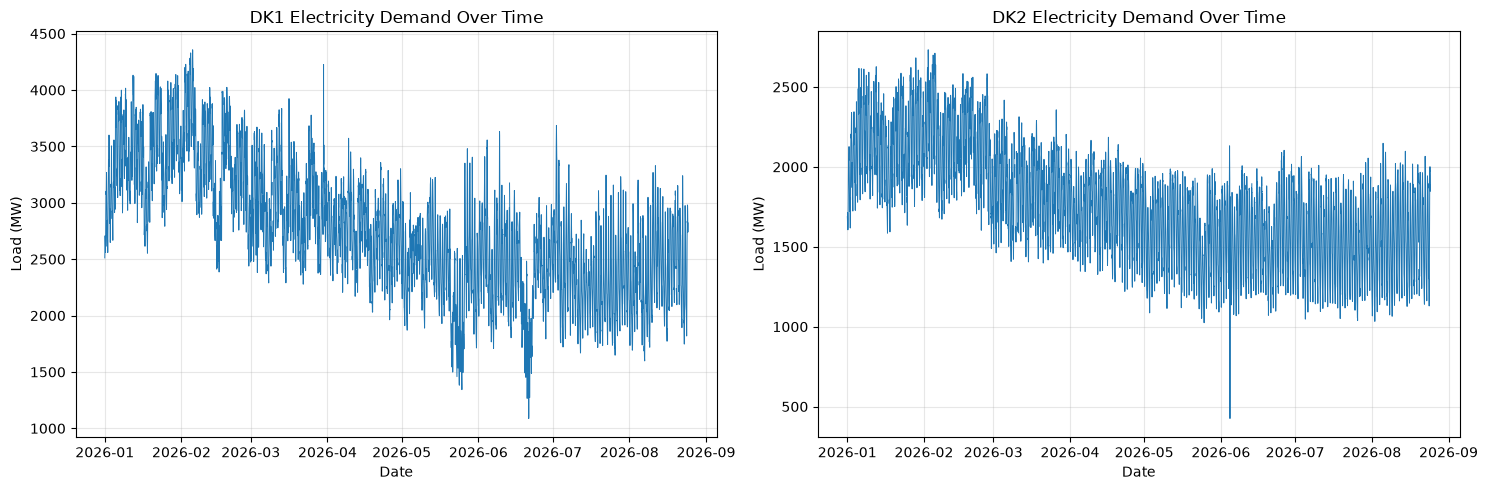

In [ ]:
# Load over time
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(
    DK1["start_time"],
    DK1["Actual Total Load (MW)"],
    linewidth=0.7
)

ax1.set_title("DK1 Electricity Demand Over Time")
ax1.set_xlabel("Date")
ax1.set_ylabel("Load (MW)")
ax1.grid(alpha=0.3)

ax2.plot(
    DK2["start_time"],
    DK2["Actual Total Load (MW)"],
    linewidth=0.7
)
ax2.set_title("DK2 Electricity Demand Over Time")
ax2.set_xlabel("Date")
ax2.set_ylabel("Load (MW)")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

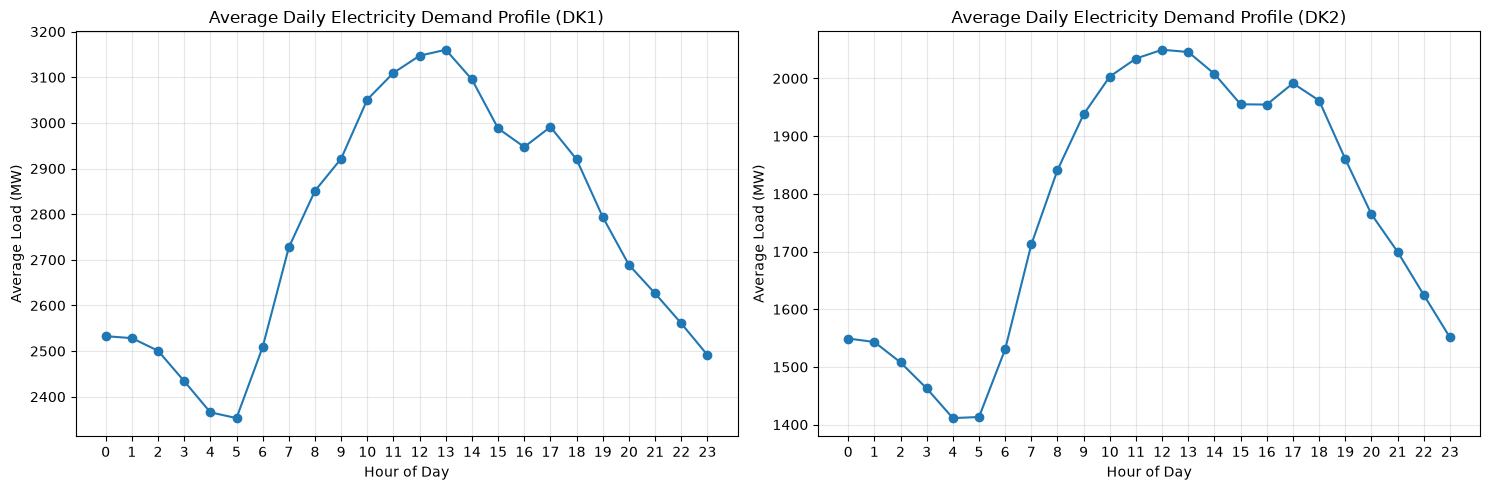

In [12]:
# Average daily profile
hourly_profile = (
    DK1.groupby("hour")["Actual Total Load (MW)"]
    .mean()
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(
    hourly_profile.index,
    hourly_profile.values,
    marker="o"
)

ax1.set_title("Average Daily Electricity Demand Profile (DK1)")
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Average Load (MW)")
ax1.set_xticks(range(24))
ax1.grid(alpha=0.3)


hourly_profile = (
    DK2.groupby("hour")["Actual Total Load (MW)"]
    .mean()
)

ax2.plot(
    hourly_profile.index,
    hourly_profile.values,
    marker="o"
)

ax2.set_title("Average Daily Electricity Demand Profile (DK2)")
ax2.set_xlabel("Hour of Day")
ax2.set_ylabel("Average Load (MW)")
ax2.set_xticks(range(24))
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

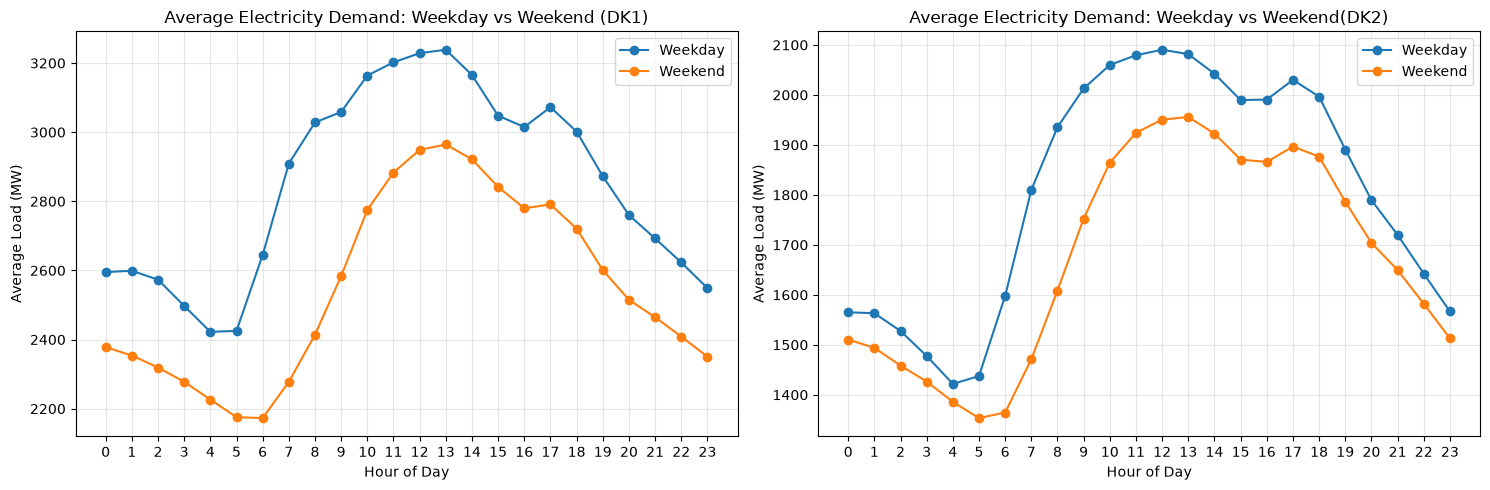

In [13]:
# Weekend vs weekday demand
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

DK1["day_type"] = DK1["is_weekend"].map({
    False: "Weekday",
    True: "Weekend"
})

daily_profile = (
    DK1.groupby(["hour", "day_type"])["Actual Total Load (MW)"]
    .mean()
    .reset_index()
)

for day_type in ["Weekday", "Weekend"]:
    subset = daily_profile[
        daily_profile["day_type"] == day_type
    ]

    ax1.plot(
        subset["hour"],
        subset["Actual Total Load (MW)"],
        marker="o",
        label=day_type
    )

ax1.set_title("Average Electricity Demand: Weekday vs Weekend (DK1)")
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Average Load (MW)")
ax1.set_xticks(range(24))
ax1.legend()
ax1.grid(alpha=0.3)


DK2["day_type"] = DK2["is_weekend"].map({
    False: "Weekday",
    True: "Weekend"
})

daily_profile = (
    DK2.groupby(["hour", "day_type"])["Actual Total Load (MW)"]
    .mean()
    .reset_index()
)

for day_type in ["Weekday", "Weekend"]:
    subset = daily_profile[
        daily_profile["day_type"] == day_type
    ]

    ax2.plot(
        subset["hour"],
        subset["Actual Total Load (MW)"],
        marker="o",
        label=day_type
    )

ax2.set_title("Average Electricity Demand: Weekday vs Weekend(DK2)")
ax2.set_xlabel("Hour of Day")
ax2.set_ylabel("Average Load (MW)")
ax2.set_xticks(range(24))
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

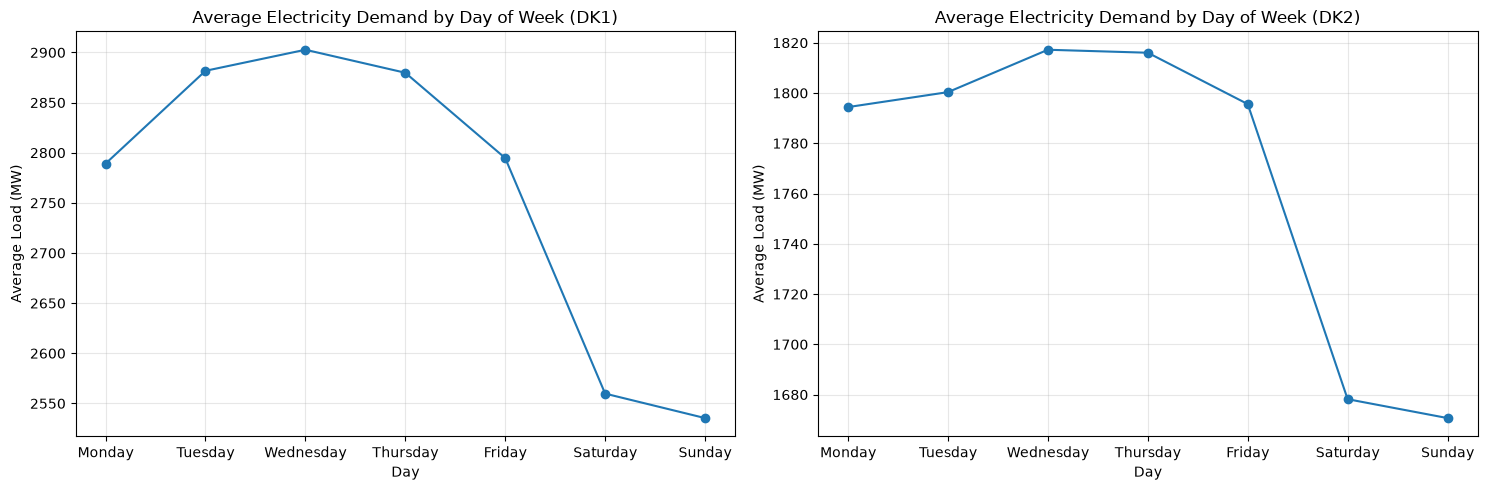

In [14]:
# Weekly load profile
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

weekly_profile = (
    DK1.groupby("day_of_week")["Actual Total Load (MW)"]
    .mean()
)

day_labels = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]


ax1.plot(
    day_labels,
    weekly_profile.values,
    marker="o"
)

ax1.set_title("Average Electricity Demand by Day of Week (DK1)")
ax1.set_xlabel("Day")
ax1.set_ylabel("Average Load (MW)")
ax1.grid(alpha=0.3)

weekly_profile = (
    DK2.groupby("day_of_week")["Actual Total Load (MW)"]
    .mean()
)

ax2.plot(
    day_labels,
    weekly_profile.values,
    marker="o"
)
ax2.set_title("Average Electricity Demand by Day of Week (DK2)")
ax2.set_xlabel("Day")
ax2.set_ylabel("Average Load (MW)")
ax2.grid(alpha=0.3)



plt.tight_layout()
plt.show()

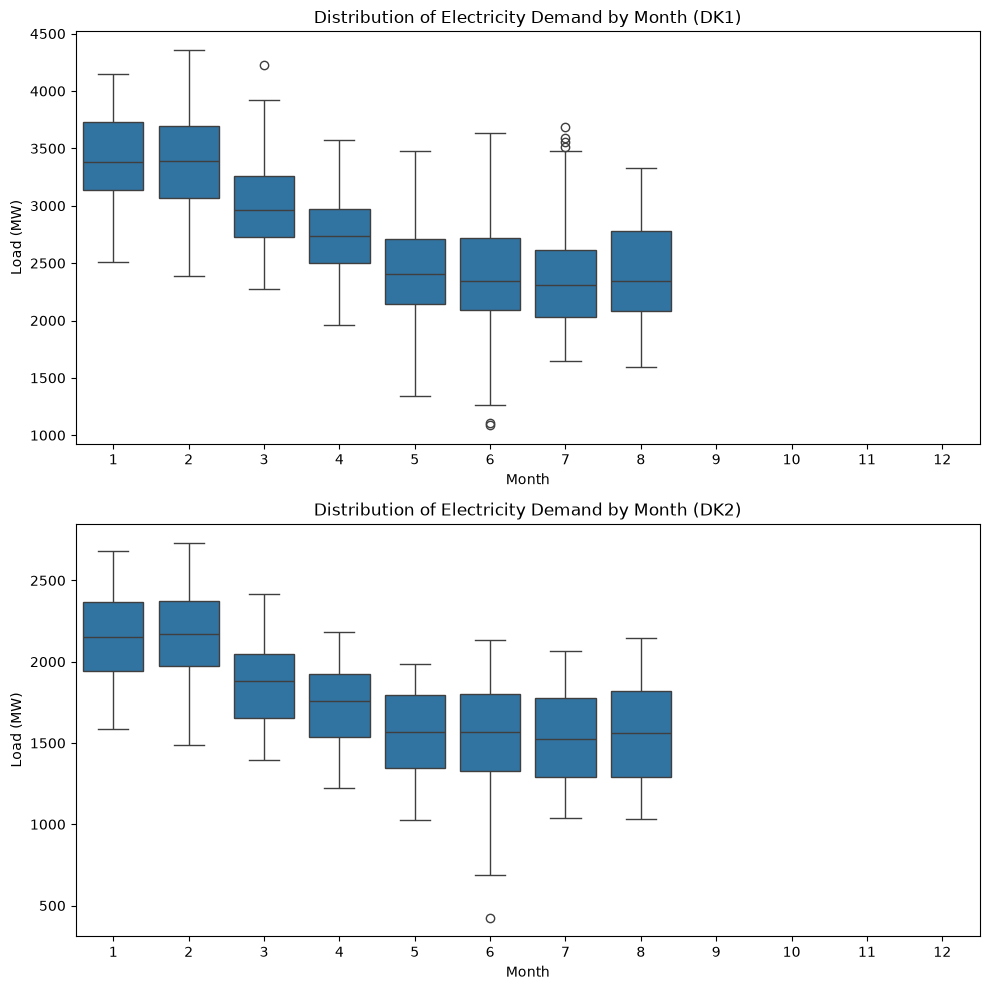

In [15]:
# Monthly distribution of electricity demand, DK1
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# DK1
sns.boxplot(
    data=DK1,
    x="month",
    y="Actual Total Load (MW)",
    ax=axes[0]
)
axes[0].set_title("Distribution of Electricity Demand by Month (DK1)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Load (MW)")

# DK2
sns.boxplot(
    data=DK2,
    x="month",
    y="Actual Total Load (MW)",
    ax=axes[1]
)
axes[1].set_title("Distribution of Electricity Demand by Month (DK2)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Load (MW)")

plt.tight_layout()
plt.show()

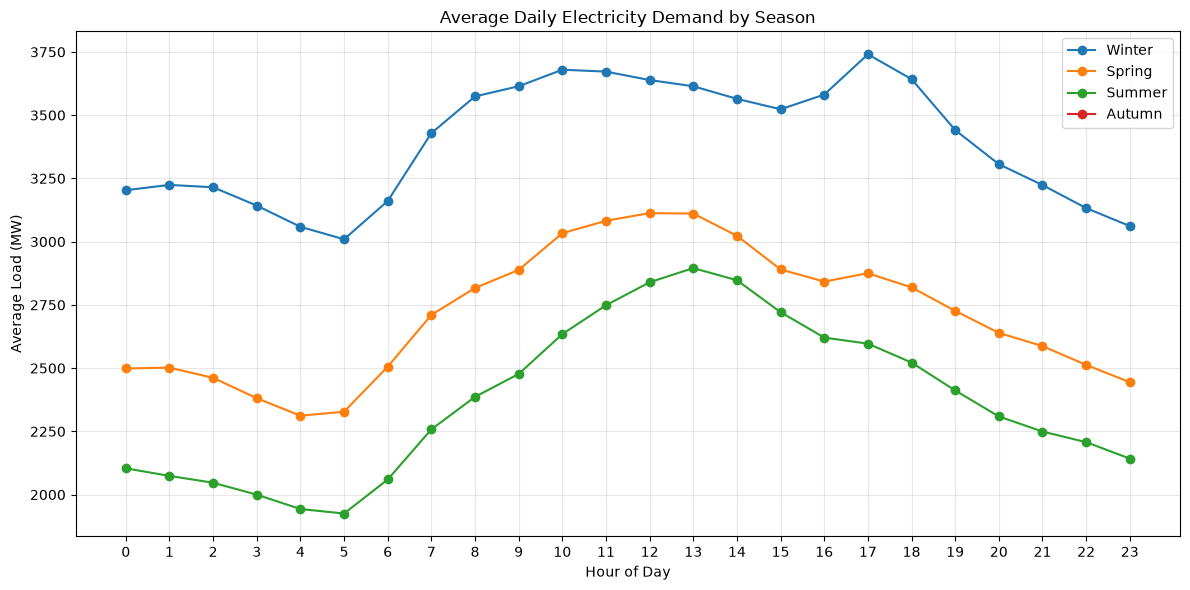

In [19]:
# Energy demand based on season
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

DK1["season"] = DK1["month"].apply(get_season)

seasonal_profile = (
    DK1.groupby(["season", "hour"])["Actual Total Load (MW)"]
    .mean()
    .reset_index()
)

season_order = [
    "Winter",
    "Spring",
    "Summer",
    "Autumn"
]

plt.figure(figsize=(12, 6))

for season in season_order:

    subset = seasonal_profile[
        seasonal_profile["season"] == season
    ]

    plt.plot(
        subset["hour"],
        subset["Actual Total Load (MW)"],
        marker="o",
        label=season
    )

plt.title("Average Daily Electricity Demand by Season")
plt.xlabel("Hour of Day")
plt.ylabel("Average Load (MW)")
plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

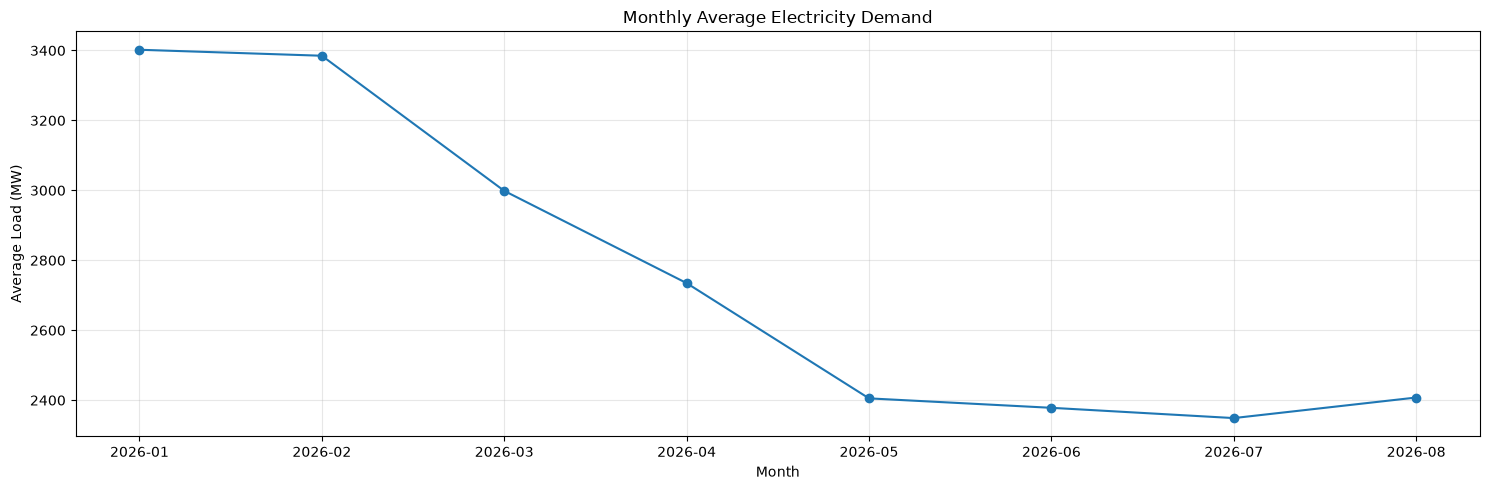

In [20]:
# Monthly average demand
monthly_average = (
    DK1.groupby(DK1["start_time"].dt.to_period("M"))["Actual Total Load (MW)"]
    .mean()
)

plt.figure(figsize=(15, 5))

plt.plot(
    monthly_average.index.astype(str),
    monthly_average.values,
    marker="o"
)

plt.title("Monthly Average Electricity Demand")
plt.xlabel("Month")
plt.ylabel("Average Load (MW)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The analysis of electricity demand under varying temporal conditions reveals a key insight: *electricity demand exhibits systematic and largely intuitive temporal pattern* Over the course of the year, *demand is generally higher during the first quarter*, followed by a *gradual decline as temperatures increase and the warmer months approach*. This pattern suggests a seasonal relationship between electricity consumption and ambient temperature, with colder periods associated with greater electricity demand, potentially due to increased heating requirements.
A similar pattern is observed at the hourly level. *Electricity demand follows a distinct daily load profile, with demand increasing throughout the morning and reaching higher levels around midday*, coinciding with periods of increased economic and human activity. Furthermore, demand is consistently higher on weekdays than on weekends. This weekday–weekend variation is consistent with Denmark's industrial and agricultural activities, where electricity consumption is influenced by regular working schedules and operational requirements.

At the weekly level, demand reaches its highest levels during the working week, with Wednesday exhibiting the highest observed demand, while Sunday records the lowest. Finally, the seasonal analysis reinforces the relationship between electricity demand and temperature, with demand generally increasing during the colder months and decreasing during warmer periods. 

*Overall, these patterns indicate that electricity demand is strongly influenced by temporal factors, including seasonality, time of day, and the distinction between working and non-working days.*


In [21]:
# Outliers
top_demand = (
    DK1.nlargest(20, "Actual Total Load (MW)")
    [["Actual Total Load (MW)", "Day-ahead Total Load Forecast (MW)"]]
)
print("Top 20 highest electricity demand:")
display(top_demand)

least_demand = (
    DK1.nsmallest(20, "Actual Total Load (MW)")
    [["Actual Total Load (MW)", "Day-ahead Total Load Forecast (MW)"]]
)
print("Top 20 lowest electricity demand:")
display(least_demand)

Top 20 highest electricity demand:


,Actual Total Load (MW),Day-ahead Total Load Forecast (MW)
852,4356.93,4231.00
853,4347.07,4282.00
833,4328.99,4308.00
851,4315.27,4205.00
826,4282.09,4158.00
827,4272.70,4123.00
850,4261.90,4165.00
854,4259.75,4191.00
829,4240.02,4154.00
785,4227.85,4217.00


Top 20 lowest electricity demand:


,Actual Total Load (MW),Day-ahead Total Load Forecast (MW)
4111,1087.22,1353.00
4112,1110.43,1229.10
4096,1265.46,1250.00
4120,1272.31,1287.50
4110,1308.14,1485.50
3463,1343.35,1472.00
3438,1382.56,1467.00
3437,1395.22,1462.00
4109,1405.49,1495.60
4095,1419.22,1727.00


The outlier analysis identifies the extreme scales in which demand forecasting exists on. With the former table showing the days of highest demand and the latter, the days of the lowest demand. 

Examining these outliers provides insight into the conditions and temporal patterns associated with forecasting errors. Identifying systematic relationships within these deviations can support the refinement of forecasting models by enabling more targeted adjustments and improving model performance under specific demand conditions.

In [ ]:
# Analyze forecast error 
# Ensure that the forecasted load is numeric
DK1["Day-ahead Total Load Forecast (MW)"] = pd.to_numeric(
    DK1["Day-ahead Total Load Forecast (MW)"],
    errors="coerce"
)

DK2["Day-ahead Total Load Forecast (MW)"] = pd.to_numeric(
    DK2["Day-ahead Total Load Forecast (MW)"],
    errors="coerce"
)

Forecasting error statistics:


count    5646.000000
mean        7.581015
std       127.280694
min      -815.880000
25%       -29.395000
50%         3.965000
75%        41.482500
max      1114.760000
Name: Forecast Error, dtype: float64

Largest forecasting errors:


,Forecast Error,Actual Total Load (MW),Day-ahead Total Load Forecast (MW)
2121,1114.76,4226.76,3112.0
218,789.79,3391.79,2602.0
84,782.05,3183.05,2401.0
370,766.78,3870.78,3104.0
85,763.69,3161.69,2398.0
83,755.38,3173.38,2418.0
82,737.63,3160.63,2423.0
368,727.16,3767.16,3040.0
219,719.51,3229.51,2510.0
369,715.36,3791.36,3076.0


Smallest forecasting errors:


,Forecast Error,Actual Total Load (MW),Day-ahead Total Load Forecast (MW)
3399,-815.88,1742.12,2558.0
359,-794.65,2956.35,3751.0
358,-758.78,3013.22,3772.0
815,-745.49,3368.51,4114.0
28,-745.16,2588.84,3334.0
29,-722.73,2559.27,3282.0
119,-701.45,3150.55,3852.0
287,-700.49,3161.51,3862.0
316,-694.91,2824.09,3519.0
3398,-690.38,2005.62,2696.0


Plot of Forecast Error Distribution:


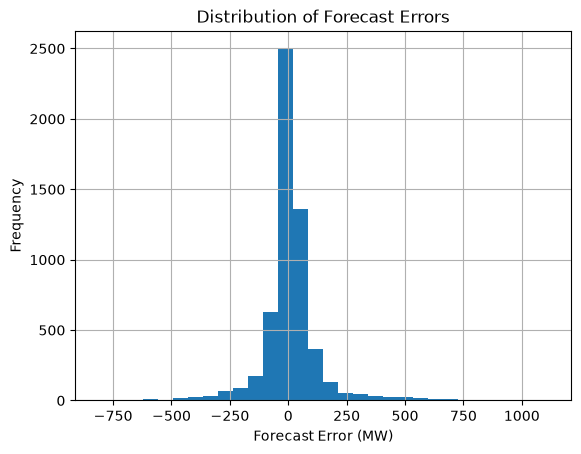

In [40]:
# Forecast Error
DK1["Forecast Error"] = (
    DK1["Actual Total Load (MW)"] - DK1["Day-ahead Total Load Forecast (MW)"]
)
print("Forecasting error statistics:")
display(DK1["Forecast Error"].describe())

print("Largest forecasting errors:")
display(DK1.nlargest(10, "Forecast Error")[["Forecast Error", "Actual Total Load (MW)", "Day-ahead Total Load Forecast (MW)"]])

print("Smallest forecasting errors:")
display(DK1.nsmallest(10, "Forecast Error")[["Forecast Error", "Actual Total Load (MW)", "Day-ahead Total Load Forecast (MW)"]])

print("Plot of Forecast Error Distribution:")
DK1["Forecast Error"].hist(bins=30)
plt.xlabel("Forecast Error (MW)")
plt.ylabel("Frequency")
plt.title("Distribution of Forecast Errors")
plt.show()


    hour        mean         mae        rmse         std
0      0   32.310763   61.446864  110.214686  105.596116
1      1   17.985254   52.263305  110.579474  109.338957
2      2   14.835277   57.245064  128.409964  127.822374
3      3   -1.735254   63.409661  135.594438  135.871503
4      4  -17.693390   62.248051  135.813700  134.942446
5      5   -7.488390   51.932966  116.213958  116.218933
6      6   52.238347   77.684958  117.559265  105.539249
7      7   58.918432   85.991059  147.265112  135.252153
8      8   35.361102   77.505847  142.555109  138.393306
9      9   34.036780   74.903898  128.832118  124.518717
10    10   41.887830   79.831830  149.380446  143.693390
11    11   41.482809   71.512681  122.283106  115.277418
12    12   43.154145   72.931410  128.367389  121.155419
13    13   29.287702   64.692213  119.527247  116.130883
14    14    6.148093   54.554280   91.081831   91.067237
15    15   10.005660   52.924809   98.031082   97.727278
16    16   20.573856   57.95470

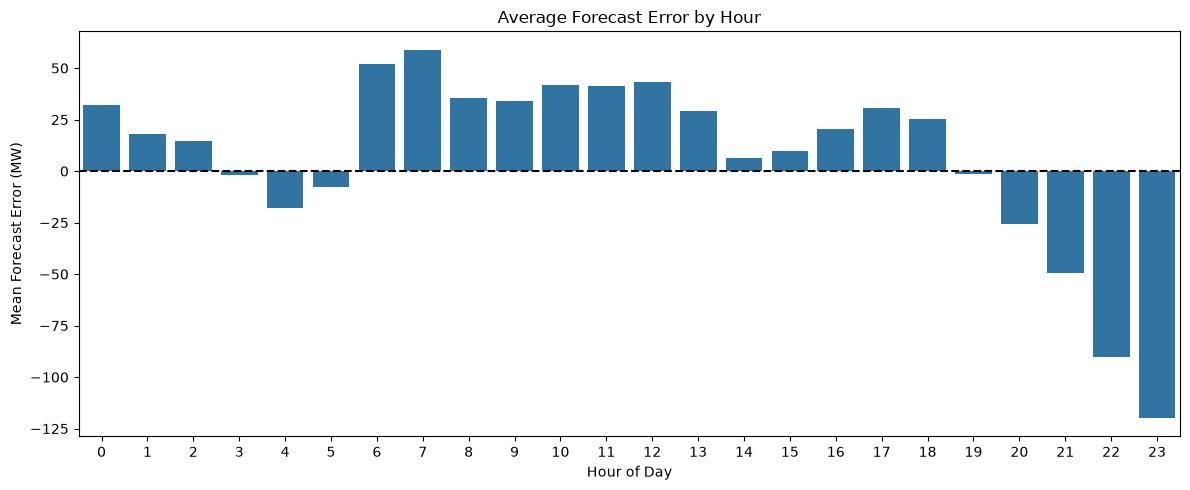

   day_of_week   day_name       mean        mae        rmse         std
0            0     Monday   4.929938  87.075304  147.440971  147.450140
1            1    Tuesday  -2.750076  74.485505  129.662861  129.715611
2            2  Wednesday   5.882101  71.295595  122.461925  122.398071
3            3   Thursday   5.783752  70.205326  120.190074  120.124731
4            4     Friday   4.422206  78.018995  142.220515  142.238929
5            5   Saturday  19.029080  57.201620  108.919968  107.310685
6            6     Sunday  15.393374  60.620834  117.200041  116.256083


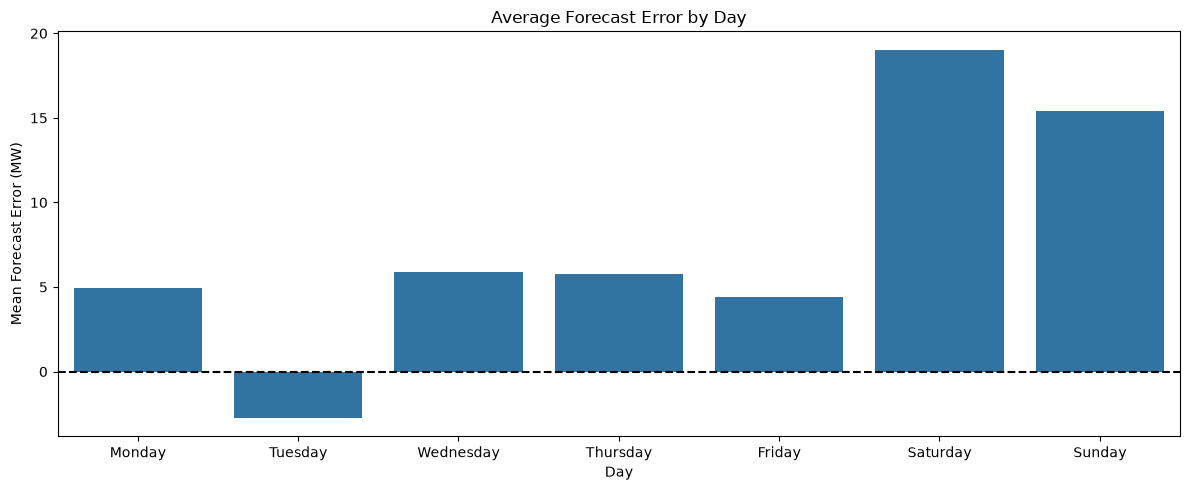

    month month_name       mean         mae        rmse         std
0       1    January  80.154892  198.155806  271.728994  259.812564
1       2   February   8.465536   80.624435  117.335934  117.117324
2       3      March   9.355054   61.677033  100.211359   99.841408
3       4      April  -8.879958   50.984375   83.282254   82.865054
4       5        May -16.036586   49.848381   92.800987   91.466614
5       6       June  -9.599722   46.896412   77.849073   77.308705
6       7       July  -1.942110   33.438481   52.002716   52.001397
7       8     August  -4.932905   40.156778   65.450077   65.321445
8       9  September        NaN         NaN         NaN         NaN
9      10    October        NaN         NaN         NaN         NaN
10     11   November        NaN         NaN         NaN         NaN
11     12   December        NaN         NaN         NaN         NaN


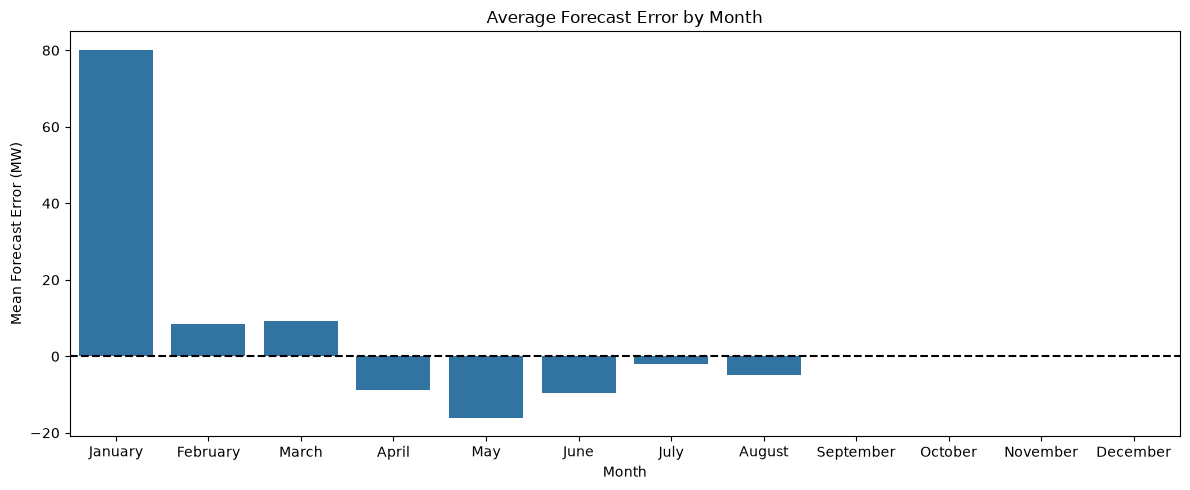

   is_weekend       mean        mae        rmse         std
0       False   3.672338  76.233090  132.881119  132.846905
1        True  17.211227  58.911227  113.135779  111.853269


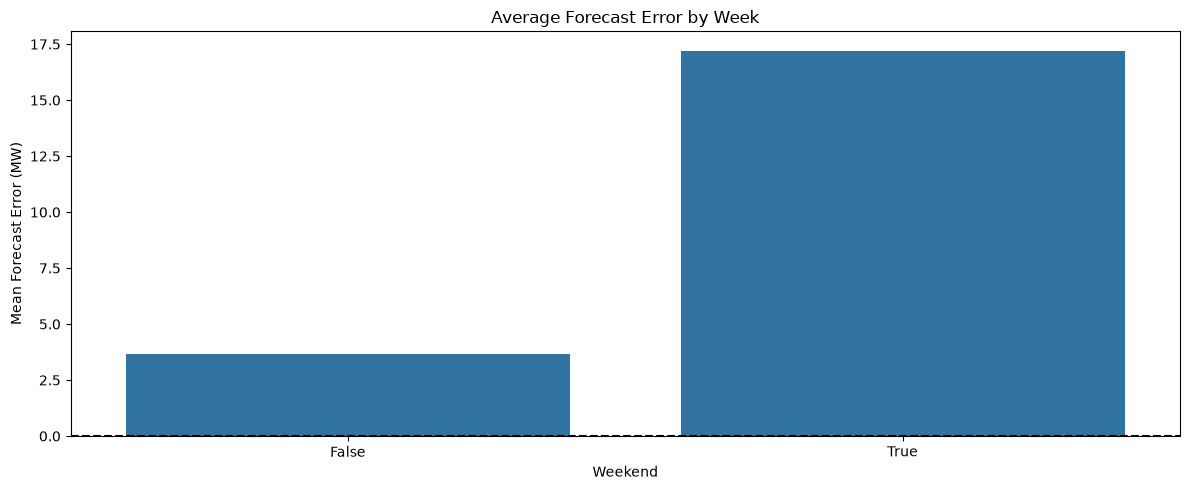

In [ ]:
# Error analysis: When is ENTSOE-E most likely to make errors in its forecasts?
# Hourly error analysis
hourly_error = (
    DK1.groupby("hour")["Forecast Error"]
    .agg(
        mean="mean",
        mae=lambda x: x.abs().mean(),
        rmse=lambda x: np.sqrt((x ** 2).mean()),
        std="std"
    )
    .reset_index()
)
print(hourly_error)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=hourly_error,
    x="hour",
    y="mean"
)

plt.axhline(0, color="black", linestyle="--")
plt.title("Average Forecast Error by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Mean Forecast Error (MW)")
plt.tight_layout()
plt.show()

# Day error analysis
daily_error = (
    DK1.groupby(["day_of_week", "day_name"])["Forecast Error"]
    .agg(
        mean = "mean",
        mae=lambda x: x.abs().mean(),
        rmse=lambda x: np.sqrt((x ** 2).mean()),
        std="std"
    )
    .reset_index()
) 
print(daily_error)

plt.figure(figsize=(12,5))

sns.barplot(
    data = daily_error,
    x="day_name",
    y="mean"
)

plt.axhline(0, color="black", linestyle="--")
plt.title("Average Forecast Error by Day")
plt.xlabel("Day")
plt.ylabel("Mean Forecast Error (MW)")
plt.tight_layout()
plt.show()

# Monthly error analysis
monthly_error = (
    DK1.groupby(["month", "month_name"])["Forecast Error"]
    .agg(
        mean = "mean",
        mae=lambda x: x.abs().mean(),
        rmse=lambda x: np.sqrt((x ** 2).mean()),
        std="std"
    )
    .reset_index()
) 
print(monthly_error)

plt.figure(figsize=(12,5))

sns.barplot(
    data = monthly_error,
    x="month_name",
    y="mean"
)

plt.axhline(0, color="black", linestyle="--")
plt.title("Average Forecast Error by Month")
plt.xlabel("Month")
plt.ylabel("Mean Forecast Error (MW)")
plt.tight_layout()
plt.show()

# Weekend vs weekday error analysis
weekend_error = (
    DK1.groupby("is_weekend")["Forecast Error"]
    .agg(
        mean = "mean",
        mae=lambda x: x.abs().mean(),
        rmse=lambda x: np.sqrt((x ** 2).mean()),
        std="std"
    )
    .reset_index()
) 

print(weekend_error)

plt.figure(figsize=(12,5))

sns.barplot(
    data = weekend_error,
    x="is_weekend",
    y="mean"
)

plt.axhline(0, color="black", linestyle="--")
plt.title("Average Forecast Error by Week")
plt.xlabel("Weekend")
plt.ylabel("Mean Forecast Error (MW)")
plt.tight_layout()
plt.show()



   is_holiday       mean        mae         std
0       False   6.892538  71.162651  126.725949
1        True  27.138073  73.209844  141.103133


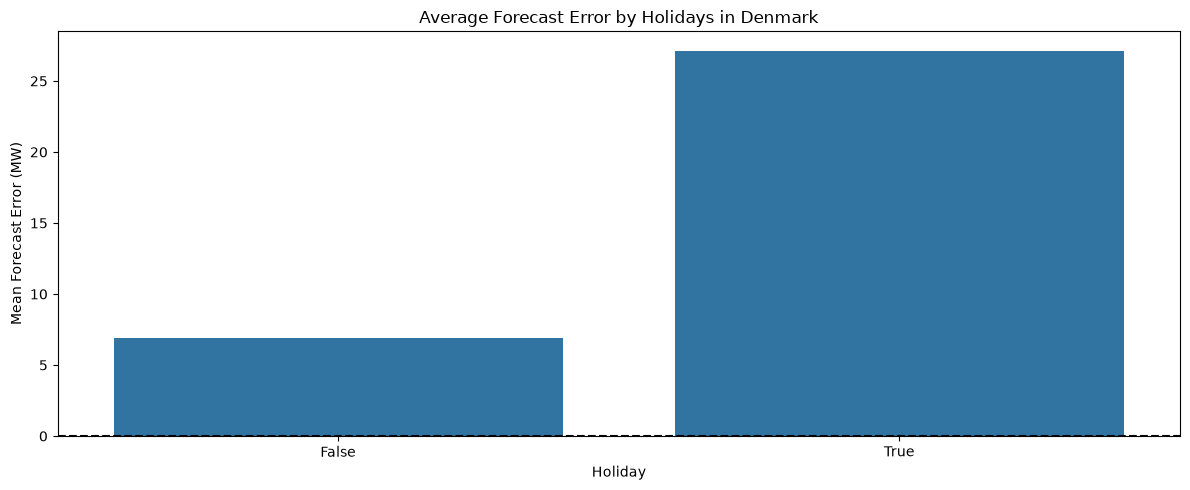

In [25]:
# Holiday error
dk_holidays = holidays.Denmark(years=2026)
DK1["is_holiday"] = DK1["start_time"].dt.date.isin(dk_holidays)

holiday_error = (
    DK1.groupby("is_holiday")["Forecast Error"]
    .agg(
        mean="mean",
        mae=lambda x: x.abs().mean(),
        std="std"
    )
    .reset_index()
)
print(holiday_error)

plt.figure(figsize=(12,5))

sns.barplot(
    data = holiday_error,
    x="is_holiday",
    y="mean"
)

plt.axhline(0, color="black", linestyle="--")
plt.title("Average Forecast Error by Holidays in Denmark")
plt.xlabel("Holiday")
plt.ylabel("Mean Forecast Error (MW)")
plt.tight_layout()
plt.show()



The error analysis reveals disparities between forecasting and actual demand. The mean error is merely 7 MW – revealing high precision in the forecasting models. To further understand the error in forecasting, the maximum and minimum deviation in forecasting has been extracted. Here, the largest error was observed at 1114.76 MW and the least at -815.88 MW. 

In electricity demand, over-forecasting results to the production of unnecessary amounts of electricity. This can lead to unnecessary generation, imbalance costs or inefficient use of generation resources. Converse, under-forecasting can become costly, with the demand being met through external sources such as intraday markets.


The data analysis is followed by the development and evaluation of a predictive model. The primary objective is to develop a forecasting model capable of achieving performance comparable to, or exceeding, that of ENTSO-E. 
The modeling process therefore focuses on minimizing the forecasting error between predicted and actual electricity demand, while evaluating the model’s ability to generalize across different temporal and demand conditions.

In [ ]:
# 2. MODEL TRAINING
# Forecasting benchmark
    # Sort data
DK1 = DK1.sort_index()

    # Baseline #1: Energy demand based on previous hour

DK1["baseline_previous_hour"] = (
    DK1["Actual Total Load (MW)"].shift(1)
)

    # Baseline #2: Energy demand based on previous day
DK1["baseline_previous_day"] = (
    DK1["Actual Total Load (MW)"].shift(24)
) 

    # Baseline #3: Energy demand previous week
DK1["baseline_previous_week"] = (
    DK1["Actual Total Load (MW)"].shift(168)
) 

# Compare baseline prediciton to actual demand
    # Hour
actual = DK1["Actual Total Load (MW)"]
baseline_hour = DK1["baseline_previous_hour"]

mask = actual.notna() & baseline_hour.notna()

mae_previous_hour = mean_absolute_error(
    actual[mask],
    baseline_hour[mask]
)

rmse_hour = root_mean_squared_error(
    actual[mask],
    baseline_hour[mask]
)

bias_hour = (baseline_hour[mask] - actual[mask]).mean()

p95_hour = np.percentile(
    np.abs(baseline_hour[mask] - actual[mask]),
    95
)
print("Hour evaluation benchmark:")
print("Previous-hour baseline MAE:", mae_previous_hour)
print("Previous-hour baseline RMSE:", rmse_hour)
print("Previous-hour baseline Bias:", bias_hour)
print("Previous-hour baseline 95th percentile absolute error:", p95_hour)
print()

    # Previous day
baseline_previous_day = DK1["baseline_previous_day"]

mask = actual.notna() & baseline_previous_day.notna()

mae_previous_day = mean_absolute_error(
    actual[mask],
    baseline_previous_day[mask]
)

rmse_day = root_mean_squared_error(
    actual[mask],
    baseline_previous_day[mask]
)

bias_day = (baseline_previous_day[mask] - actual[mask]).mean()

p95_day = np.percentile(
    np.abs(baseline_previous_day[mask] - actual[mask]),
    95
)
print("Day evaluation benchmark:")
print("Previous-day baseline MAE:", mae_previous_day)
print("Previous-day baseline RMSE:", rmse_day)
print("Previous-day baseline Bias:", bias_day)
print("Previous-day baseline 95th percentile absolute error:", p95_day)
print()

    # Previous week
baseline_previous_week = DK1["baseline_previous_week"]

mask = actual.notna() & baseline_previous_week.notna()

mae_previous_week = mean_absolute_error(
    actual[mask],
    baseline_previous_week[mask]
)
rmse_week = root_mean_squared_error(
    actual[mask],
    baseline_previous_week[mask]
)

bias_week = (baseline_previous_week[mask] - actual[mask]).mean()

p95_week = np.percentile(
    np.abs(baseline_previous_week[mask] - actual[mask]),
    95
)
print("Week evaluation benchmark:")
print("Previous-week baseline MAE:", mae_previous_week)
print("Previous-week baseline RMSE:", rmse_week)
print("Previous-week baseline Bias:", bias_week)
print("Previous-week baseline 95th percentile absolute error:", p95_week)
print()

# ENTSOE-E forecast
actual = DK1["Actual Total Load (MW)"]
entsoe = DK1["Day-ahead Total Load Forecast (MW)"]

mask = actual.notna() & entsoe.notna()

mae_entsoe = mean_absolute_error(
    actual[mask],
    entsoe[mask]
)

rmse_entsoe = root_mean_squared_error(
    actual[mask],
    entsoe[mask]
)

bias_entsoe = (entsoe[mask] - actual[mask]).mean()

p95_entsoe = np.percentile(
    np.abs(entsoe[mask] - actual[mask]),
    95
)
print("ENTSO-E evaluation benchmark:")
print("ENTSO-E forecasting MAE:", mae_entsoe)
print("ENTSO-E forecasting RMSE:", rmse_entsoe)
print("ENTSO-E forecasting Bias:", bias_entsoe)
print("ENTSOE-E 95th percentile absolute error:", p95_entsoe)


Hour evaluation benchmark:
Previous-hour baseline MAE: 97.5481982621032
Previous-hour baseline RMSE: 129.04063186460425
Previous-hour baseline Bias: -0.1516705089554886
Previous-hour baseline 95th percentile absolute error: 258.14200000000034

Day evaluation benchmark:
Previous-day baseline MAE: 190.81656211014078
Previous-day baseline RMSE: 268.6383892590423
Previous-day baseline Bias: 2.013510960613081
Previous-day baseline 95th percentile absolute error: 601.4300000000001

Week evaluation benchmark:
Previous-week baseline MAE: 239.45103675260563
Previous-week baseline RMSE: 325.9387451432477
Previous-week baseline Bias: 22.585021027610168
Previous-week baseline 95th percentile absolute error: 675.2799999999984

ENTSO-E evaluation benchmark:
ENTSO-E forecasting MAE: 71.2322688629118
ENTSO-E forecasting RMSE: 127.49500995152654
ENTSO-E forecasting Bias: -7.581014877789584
ENTSOE-E 95th percentile absolute error: 283.1725000000001


In [47]:
# Built dataset
features = [
    "hour",
    "day_of_week",
    "is_weekend",
    "month",
    "baseline_previous_hour",
    "baseline_previous_day",
    "baseline_previous_week"
]

X = DK1[features]
y = DK1["Actual Total Load (MW)"]

In [75]:
# Train / Test split
# Only data where actual demand is available
historical = DK1[
    DK1["Actual Total Load (MW)"].notna()
].copy()

# Future data where actual demand isn't available
future = DK1[
    DK1["Actual Total Load (MW)"].isna()
].copy()

# Chronological 80/20 split
split = int(len(historical) * 0.8)

train = historical.iloc[:split].copy()
test = historical.iloc[split:].copy()

X_train = train[features]
y_train = train["Actual Total Load (MW)"]

X_test = test[features]
y_test = test["Actual Total Load (MW)"]

In [77]:
# XGBoost
xgb_pipeline = Pipeline([
    ("model", xgb.XGBRegressor(
        objective="reg:squarederror",
        eval_metric="mae",
        random_state=42,
        n_jobs=-1
    ))
])

# Hyperparameter grid
param_grid_xgb = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__min_child_weight": [1, 3, 5],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

# Time-series CV
tscv = TimeSeriesSplit(n_splits=5)

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

print("Best parameters:")
print(xgb_grid.best_params_)

print("Best MAE:")
print(-xgb_grid.best_score_)

best_xgb = xgb_grid.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best parameters:
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 200, 'model__subsample': 1.0}
Best MAE:
79.04328541986993


In [78]:
# XGBoost model evaluation
mask = y_test.notna() & pd.Series(y_pred_xgb, index=y_test.index).notna()

actual = y_test[mask]
predicted = pd.Series(y_pred_xgb, index=y_test.index)[mask]

test_mae = mean_absolute_error(actual, predicted)
test_rmse = root_mean_squared_error(actual, predicted)
test_bias = (predicted - actual).mean()
test_95 = np.percentile(np.abs(predicted - actual), 95)

print("Final test MAE:", test_mae)
print("Final test RMSE:", test_rmse)
print("Final test Bias:", test_bias)
print("Final test 95th percentile:", test_95)

Final test MAE: 57.10315121162887
Final test RMSE: 81.98554410714584
Final test Bias: 3.8830065507466838
Final test 95th percentile: 163.11262548828117


     Model        MAE        RMSE      Bias        95th
0  ENTSO-E  71.232269  127.495010 -7.581015  283.172500
1  XGBoost  57.103151   81.985544  3.883007  163.112625

Improvement percentage: 
XGBoost MAE improvement: 19.84%
XGBoost RMSE improvement: 35.70%
XGBoost 95th improvement: 42.40%


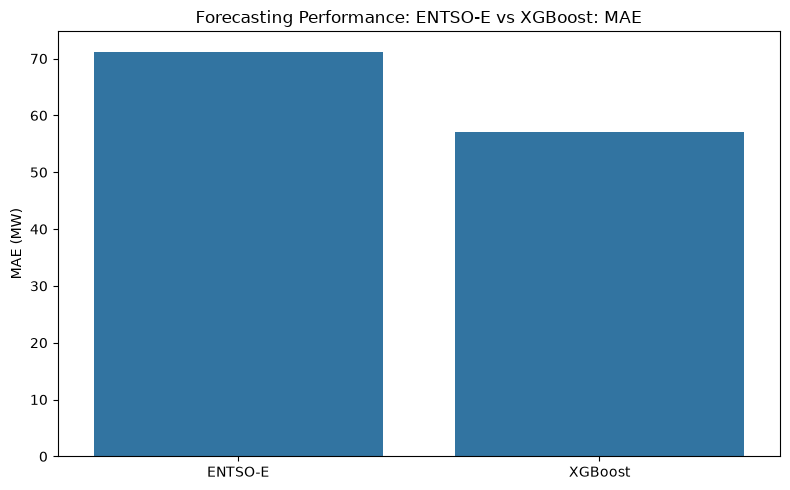

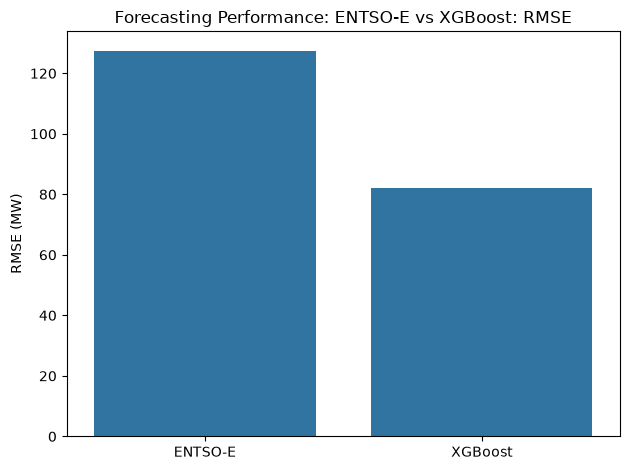

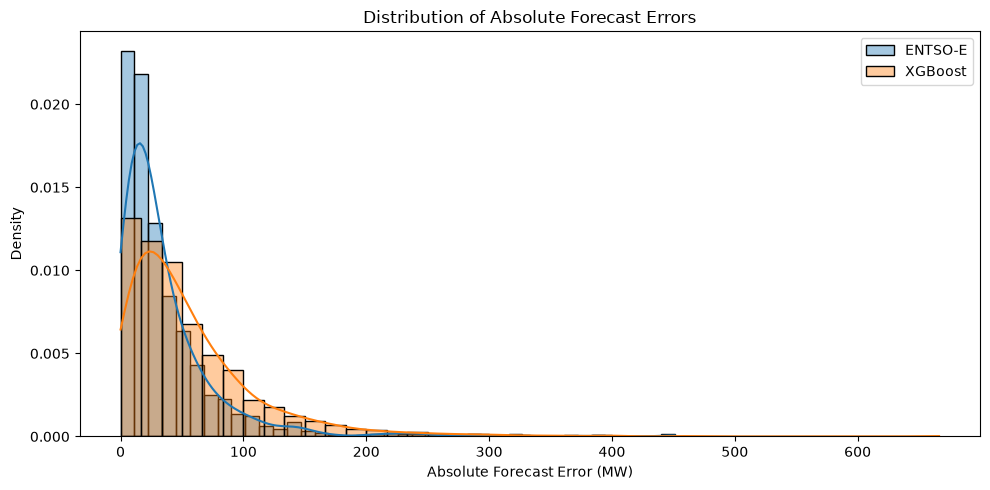

In [95]:
# XGBoost vs Benchmark
comparison = pd.DataFrame({
    "Model": ["ENTSO-E", "XGBoost"],
    "MAE": [mae_entsoe, test_mae],
    "RMSE": [rmse_entsoe, test_rmse],
    "Bias": [bias_entsoe, test_bias],
    "95th": [p95_entsoe, test_95]
})

print(comparison)
print()

print("Improvement percentage: ")

mae_improvement = (mae_entsoe - test_mae) / mae_entsoe * 100
print(f"XGBoost MAE improvement: {mae_improvement:.2f}%")
rmse_improvement = (rmse_entsoe - test_rmse) / rmse_entsoe * 100
print(f"XGBoost RMSE improvement: {rmse_improvement:.2f}%")
p95_improvement = (p95_entsoe - test_95) / p95_entsoe * 100
print(f"XGBoost 95th improvement: {p95_improvement:.2f}%")
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x="Model",
    y="MAE"
)

plt.title("Forecasting Performance: ENTSO-E vs XGBoost: MAE")
plt.ylabel("MAE (MW)")
plt.xlabel("")
plt.tight_layout()
plt.show()

sns.barplot(
    data=comparison,
    x="Model",
    y="RMSE"
)

plt.title("Forecasting Performance: ENTSO-E vs XGBoost: RMSE")
plt.ylabel("RMSE (MW)")
plt.xlabel("")
plt.tight_layout()
plt.show()


comparison_df = pd.DataFrame({
    "actual": y_test,
    "entsoe": entsoe.loc[y_test.index],
    "xgboost": y_pred_xgb
}).dropna()

entsoe_errors = np.abs(
    comparison_df["actual"] - comparison_df["entsoe"]
)

xgb_errors = np.abs(
    comparison_df["actual"] - comparison_df["xgboost"]
)

plt.figure(figsize=(10, 5))


sns.histplot(
    entsoe_errors,
    bins=40,
    kde=True,
    stat="density",
    label="ENTSO-E",
    alpha=0.4
)

sns.histplot(
    xgb_errors,
    bins=40,
    kde=True,
    stat="density",
    label="XGBoost",
    alpha=0.4
)

plt.xlabel("Absolute Forecast Error (MW)")
plt.ylabel("Density")
plt.title("Distribution of Absolute Forecast Errors")
plt.legend()
plt.tight_layout()
plt.show()

The overall performance of the XGBoost model demonstrates a substantial improvement in electricity demand forecasting accuracy compared with the established benchmark. The model achieves a 19.84% reduction in Mean Absolute Error (MAE), a 35.7% reduction in Root Mean Squared Error (RMSE), and a 42.4% reduction in the 95th percentile of the absolute forecasting error. These results indicate that XGBoost not only improves average forecasting accuracy but also substantially reduces the magnitude of larger prediction errors.

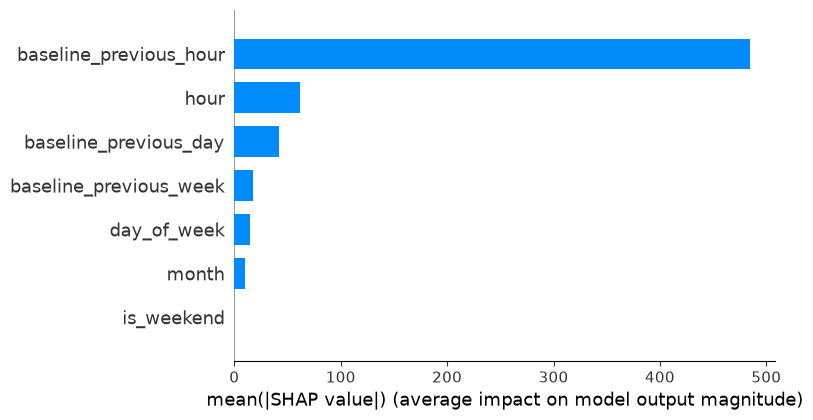

In [ ]:
# Explainer
explainer = shap.Explainer(best_xgb.named_steps["model"])
shap_values = explainer(X_test)

# Calculate SHAP values for the training dataset
shap_values = explainer.shap_values(X_test)
feature_names = X.columns

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    feature_names=feature_names
)


This indicates that the previous-hour observation was the dominant predictor of the target variable. The hour-of-day feature, extracted directly from the database, constituted the second most influential predictor, with a SHAP value of approximately 90. Consequently, both the lagged target value and the temporal information encoded by the hour-of-day feature had a substantial influence on the model's predictions.

In [ ]:
# LightGBM 
light_pipeline = Pipeline([
    ("model", lgb.LGBMRegressor(
        objective="regression",
        eval_metric="mae",
        random_state=42,
        n_jobs=-1
    ))
])

# Hyperparameter grid
param_grid_xgb = {-
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__min_child_weight": [1, 3, 5],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

# Time-series CV
tscv = TimeSeriesSplit(n_splits=5)

light_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

light_grid.fit(X_train, y_train)

print("Best parameters:")
print(light_grid.best_params_)

print("Best MAE:")
print(-light_grid.best_score_)

best_light = light_grid.best_estimator_
y_pred_light = best_light.predict(X_test)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best parameters:
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 200, 'model__subsample': 1.0}
Best MAE:
79.04328541986993


In [105]:
# LightGBM model evaluation
mask = y_test.notna() & pd.Series(y_pred_light, index=y_test.index).notna()

actual = y_test[mask]
predicted = pd.Series(y_pred_light, index=y_test.index)[mask]

test_mae_light = mean_absolute_error(actual, predicted)
test_rmse_light = root_mean_squared_error(actual, predicted)
test_bias_light = (predicted - actual).mean()
test_95_light = np.percentile(np.abs(predicted - actual), 95)

print("Final test MAE:", test_mae_light)
print("Final test RMSE:", test_rmse_light)
print("Final test Bias:", test_bias_light)
print("Final test 95th percentile:", test_95_light)

Final test MAE: 57.10315121162887
Final test RMSE: 81.98554410714584
Final test Bias: 3.8830065507466838
Final test 95th percentile: 163.11262548828117


In [109]:
# LightGBM vs ENTSOE
comparison = pd.DataFrame({
    "Model": ["ENTSO-E", "LightGBM"],
    "MAE": [mae_entsoe, test_mae_light],
    "RMSE": [rmse_entsoe, test_rmse_light],
    "Bias": [bias_entsoe, test_bias_light],
    "95th": [p95_entsoe, test_95_light]
})

print(comparison)
print()

print("Improvement percentage: ")

mae_improvement = (mae_entsoe - test_mae) / mae_entsoe * 100
print(f"LightGBM MAE improvement: {mae_improvement:.2f}%")
rmse_improvement = (rmse_entsoe - test_rmse) / rmse_entsoe * 100
print(f"LightGBM RMSE improvement: {rmse_improvement:.2f}%")
p95_improvement = (p95_entsoe - test_95) / p95_entsoe * 100
print(f"LightGBM 95th improvement: {p95_improvement:.2f}%")


      Model        MAE        RMSE      Bias        95th
0   ENTSO-E  71.232269  127.495010 -7.581015  283.172500
1  LightGBM  57.103151   81.985544  3.883007  163.112625

Improvement percentage: 
LightGBM MAE improvement: 19.84%
LightGBM RMSE improvement: 35.70%
LightGBM 95th improvement: 42.40%


After assessing that XGBoost and LightGBM preformed comparatively, I continued the with XGBoost for its stable training quality.

I0827 16:17:07.425082 31971 category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
I0827 16:17:07.427394 31971 category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


    hour         mae        rmse         std
0      0   34.648876   44.718271   28.575385
1      1   39.642755   51.219226   32.783039
2      2   36.315725   43.437452   24.089992
3      3   31.495316   41.178390   26.814228
4      4   29.229493   39.503520   26.861054
5      5   30.458052   38.736145   24.191902
6      6   53.552549   65.734274   38.531920
7      7   43.792545   54.588257   32.942067
8      8   40.725878   53.461734   35.009102
9      9   93.871949  138.209782  102.536319
10    10  105.003855  148.054326  105.504056
11    11   93.725250  116.765886   70.393759
12    12   87.908011  105.047277   58.142956
13    13   71.222288   83.638433   44.323499
14    14   75.535224   96.086333   60.017132
15    15   85.726484  132.266222  101.789888
16    16   76.206230   99.595766   64.802893
17    17   68.435103   93.191663   63.925404
18    18   62.262197   81.025553   52.411888
19    19   47.418727   61.226686   39.150784
20    20   43.747733   58.289418   38.936467
21    21  

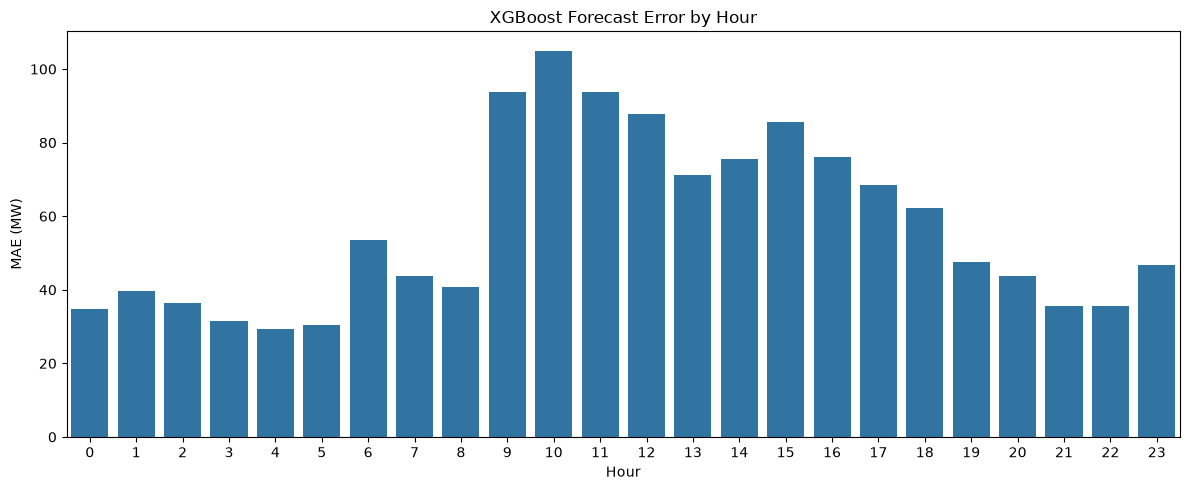

I0827 16:17:07.504759 31971 category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
I0827 16:17:07.506744 31971 category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


   day_of_week   day_name        mae       rmse        std
0            0     Monday  53.855912  71.694589  47.471735
1            1    Tuesday  56.062519  71.576208  44.654168
2            2  Wednesday  61.914466  91.066025  67.001147
3            3   Thursday  56.052789  78.955056  55.771862
4            4     Friday  47.280921  78.535938  62.896386
5            5   Saturday  61.763517  86.322232  60.486139
6            6     Sunday  62.985521  92.231315  67.576785


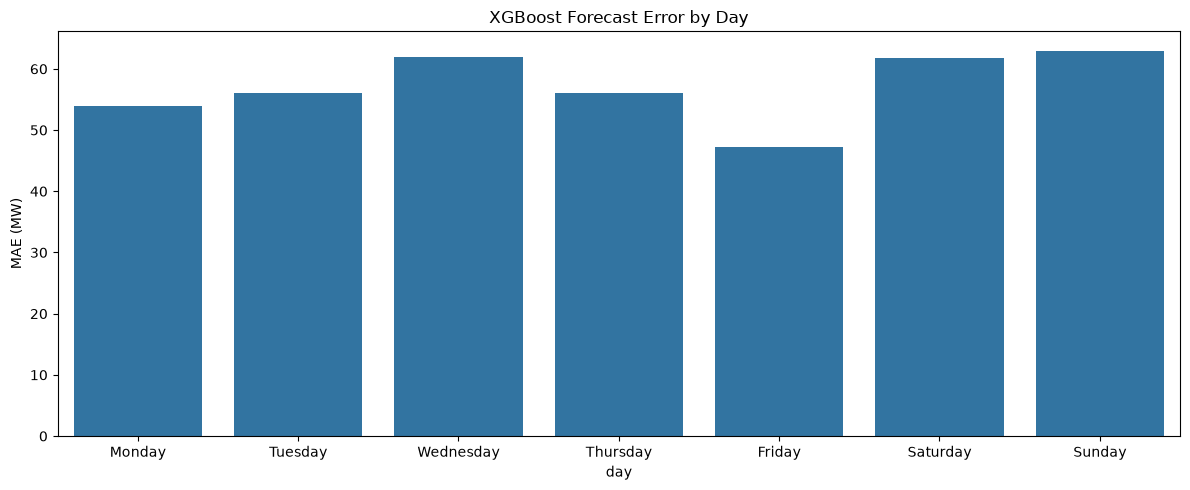

I0827 16:17:07.577111 31971 category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
I0827 16:17:07.580634 31971 category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


   month month_name        mae       rmse        std
0      7       July  55.682154  75.222939  50.621615
1      8     August  58.509138  88.167670  66.014326


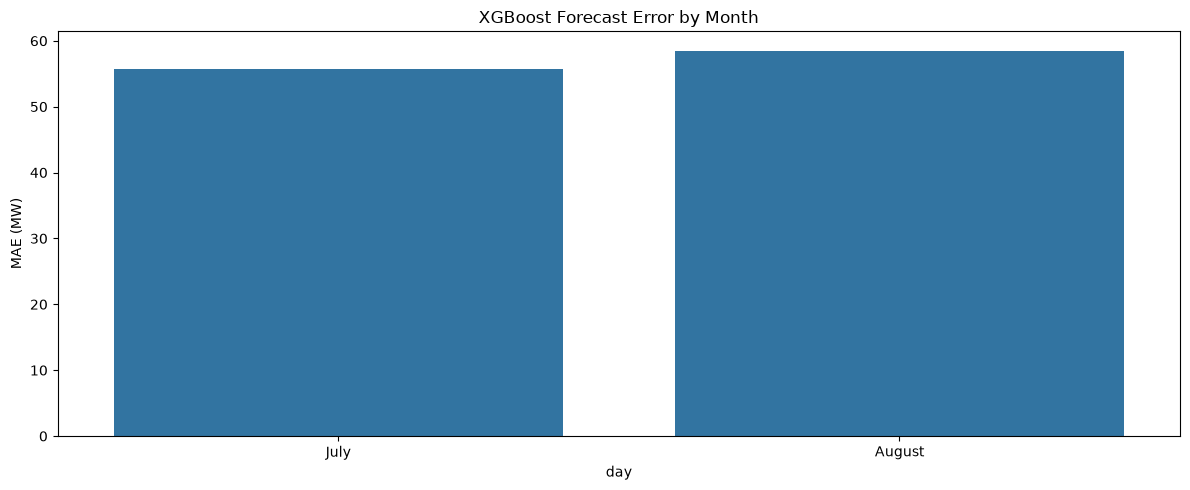

In [ ]:
# 3. MODEL EVALUATION
# Error analysis
analysis_df = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred_xgb
})

analysis_df["error"] = (
    analysis_df["predicted"] - analysis_df["actual"]
)

analysis_df["absolute_error"] = analysis_df["error"].abs()

analysis_df["hour"] = DK1.loc[y_test.index, "hour"]
analysis_df["day_of_week"] = DK1.loc[y_test.index, "day_of_week"]
analysis_df["day_name"] = DK1.loc[y_test.index, "day_name"]
analysis_df["is_weekend"] = DK1.loc[y_test.index, "is_weekend"]
analysis_df["month"] = DK1.loc[y_test.index, "month"]
analysis_df["month_name"] = DK1.loc[y_test.index, "month_name"]


# @ Which hour does XGBoost perform the worst?
hour_error = (
    analysis_df.groupby("hour")["absolute_error"]
    .agg(
        mae="mean",
        rmse=lambda x: np.sqrt(np.mean(x**2)),
        std="std"
    )
    .reset_index()
)
print(hour_error)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=hour_error,
    x="hour",
    y="mae"
)

plt.xlabel("Hour")
plt.ylabel("MAE (MW)")
plt.title("XGBoost Forecast Error by Hour")
plt.tight_layout()
plt.show()

# @ What day is XGBoost the worst?
day_error = (
    analysis_df.groupby(["day_of_week", "day_name"])["absolute_error"]
    .agg(
        mae="mean",
        rmse=lambda x: np.sqrt(np.mean(x**2)),
        std="std"
    )
    .reset_index()
)
print(day_error)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=day_error,
    x="day_name",
    y="mae"
)

plt.xlabel("day")
plt.ylabel("MAE (MW)")
plt.title("XGBoost Forecast Error by Day")
plt.tight_layout()
plt.show()

# @ what month is XGBoost the worst?
month_error = (
    analysis_df.groupby(["month", "month_name"])["absolute_error"]
    .agg(
        mae="mean",
        rmse=lambda x: np.sqrt(np.mean(x**2)),
        std="std"
    )
    .reset_index()
)
print(month_error)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=month_error,
    x="month_name",
    y="mae"
)

plt.xlabel("day")
plt.ylabel("MAE (MW)")
plt.title("XGBoost Forecast Error by Month")
plt.tight_layout()
plt.show()

# Weekend error vs weekday
weekend_error = (
    analysis_df.groupby("is_weekend")["absolute_error"]
    .agg(
        mae="mean",
        rmse=lambda x: np.sqrt(np.mean(x**2)),
        std="std"
    )
    .reset_index()
)

In [139]:
# Demand analysis: Model performance when demand is high
analysis_df["demand_group"] = pd.qcut(
    analysis_df["actual"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

demand_error = (
    analysis_df.groupby("demand_group", observed=True)
    .agg(
        entsoe_mae=("entsoe_absolute_error", "mean"),
        xgb_mae=("xgb_absolute_error", "mean"),
        entsoe_rmse=(
            "entsoe_absolute_error",
            lambda x: np.sqrt(np.mean(x**2))
        ),
        xgb_rmse=(
            "xgb_absolute_error",
            lambda x: np.sqrt(np.mean(x**2))
        )
    )
    .reset_index()
)

print(demand_error)

  demand_group  entsoe_mae    xgb_mae  entsoe_rmse    xgb_rmse
0          Low   30.114947  40.530692    61.766537   53.254579
1   Medium-Low   37.160957  46.358425    52.841495   62.964378
2  Medium-High   41.759326  65.397456    66.809259   95.461808
3         High   36.993746  76.117373    53.140732  104.745908


Analysing the demand reveals that XGBoost's overall performance does not necessarily imply superior forecasting accuracy across all demand conditions. Instead, the model's performance varies depending on the level of electricity demand, with ENTSO-E demonstrating more consistent performance across the higher-demand groups. This suggests that aggregate performance metrics may mask differences in model behavior under specific demand conditions.
